In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('sci.mplstyle')
import time


In [3]:
def viphan_ham_the_tinhdien(d,x,y,z):
    global k0, Q, R, r
    dV = k0 * Q * 1/np.sqrt(x**2+y**2+(z-d)**2)
    return dV

def hinhxuyen(x, y, z):
    global R, r
    f_hinhxuyen_squared = (R - np.sqrt(x**2+y**2))**2 +z**2
    return f_hinhxuyen_squared

def tinh_MC_thetinhdien(d, N):
    global R,r
    tich_phan = 0
    N_in = 0
    for i in range(N):
        x  = np.random.uniform(-(R+r), R+r) #Bao het hinh xuyen
        y  = np.random.uniform(-(R+r), R+r)
        z  = np.random.uniform(-r, r)
        f_hinhxuyen_squared = hinhxuyen(x,y,z)
        if f_hinhxuyen_squared <= r**2:
            dV = viphan_ham_the_tinhdien(d,x,y,z)
            tich_phan = tich_phan + dV
            N_in = N_in + 1
    V = tich_phan / N_in
    return V

In [4]:
def ghifile(d, V,thoigian_chay_MC, filename):
    filename = f"{"KQ"}_{filename}.txt"
    with open(filename, "w", encoding="utf-8") as file:
        file.write(f"# Tinh the tinh dien bang MC va Riemann \n")
        file.write(f"# Thoi gian chay la: {thoigian_chay_MC:.12f} s\n")
        file.write("#\n")
        file.write(f"# {'d':>20s} {'V':>20s}\n")

        for d_step in range(len(d)):
                file.write(f"  {d[d_step]:20.8e} {V[d_step]:20.8e}\n")

In [5]:
k0 = 8.99 * 1e9
Q = 1e-6

R= 5
r= 1

khoang_cach_xa = r *100

N = 10000

N_d = 100 #so diem d khao sat

In [6]:
# Khao sat 100 diem d tu rat xa den gan hop
d_khaosat = np.linspace(r, khoang_cach_xa, N_d)

V_khaosat = np.zeros(N_d)

print("Kich thuoc cua mang d_khao_sat = ", np.size(d_khaosat))
print("Kich thuoc cua mang V_khao_sat = ", np.size(V_khaosat))

Kich thuoc cua mang d_khao_sat =  100
Kich thuoc cua mang V_khao_sat =  100


In [7]:
thoigian_batdau_MC = time.perf_counter()

for i in range(len(d_khaosat)):
    V_khaosat[i] = tinh_MC_thetinhdien(d_khaosat[i], N)

thoigian_kethuc_MC = time.perf_counter()

thoigian_chay_MC = thoigian_kethuc_MC - thoigian_batdau_MC
print(f"Thoi gian chay bang Monte Carlo la (s): ", thoigian_chay_MC)

Thoi gian chay bang Monte Carlo la (s):  8.02677618600137


In [8]:
ghifile(d_khaosat, V_khaosat,thoigian_chay_MC,"MC_hinhxuyen")

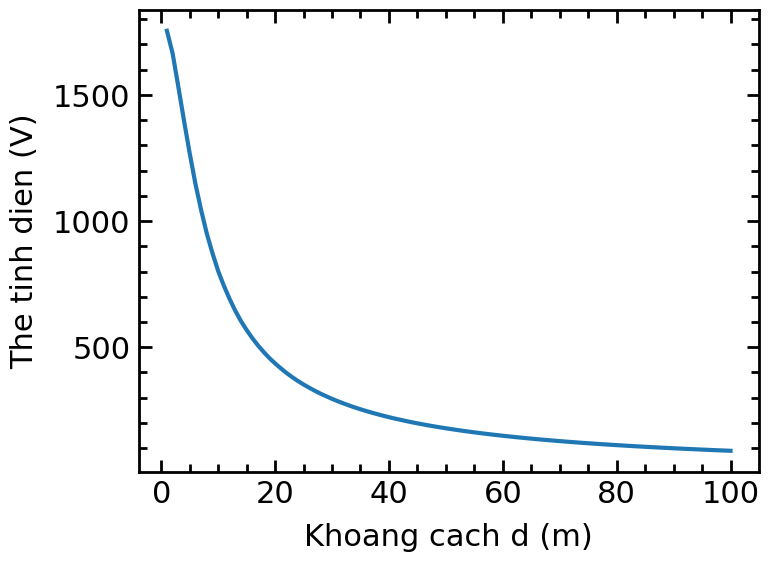

In [9]:
d_tinhdien, V_tinhdien = np.loadtxt("KQ_MC_hinhxuyen.txt", comments="#", unpack=True)


plt.figure(figsize=(8,6))
plt.plot(d_tinhdien, V_tinhdien, color="C0", lw = 3)


plt.xlabel("Khoang cach d (m)")
plt.ylabel("The tinh dien (V)")
plt.savefig("hinhxuyen.png", dpi = 300)
plt.show()

# Tong Riemann

In [10]:
# Tong Riemann
N_Riemann = 50
x_arr = np.linspace(-(R+r), R+r, N_Riemann)
y_arr = np.linspace(-(R+r), R+r, N_Riemann)
z_arr =  np.linspace(-r, r, N_Riemann) # Hinh xuyen nen tu -r den r
dx = x_arr[1] - x_arr[0]
dy = y_arr[1] - y_arr[0]
dz = z_arr[1] - z_arr[0]

dV = dx * dy * dz

In [11]:
def tinhtong_Riemann(d,x_arr,y_arr,z_arr):
    global k0, Q, R, r
    V_xuyen  = np.pi**2 * 2 * r**2 *R
    rho = Q/V_xuyen
    V = 0
    for i in range(len(x_arr)):
        for j in range(len(y_arr)):
            for k in range(len(z_arr)):
                f_hinhxuyen_squared = hinhxuyen(x_arr[i],y_arr[j],z_arr[k])
                if f_hinhxuyen_squared <= r**2:
                    V = V + dV * k0 * rho * 1/np.sqrt(x_arr[i]**2+y_arr[j]**2+(z_arr[k]-d)**2) # Phai co dV cho tong Riemann
    return V

In [12]:
# Khao sat 100 diem d tu rat xa den gan hop
d_khaosat_Riemann = np.linspace(r, khoang_cach_xa, N_d)

V_khaosat_Riemann = np.zeros(N_d)

print("Kich thuoc cua mang d_khao_sat = ", np.size(d_khaosat_Riemann))
print("Kich thuoc cua mang V_khao_sat = ", np.size(V_khaosat_Riemann))

Kich thuoc cua mang d_khao_sat =  100
Kich thuoc cua mang V_khao_sat =  100


In [13]:
thoigian_batdau_Riemann = time.perf_counter()

for i in range(len(d_khaosat_Riemann)):
    V_khaosat_Riemann[i] = tinhtong_Riemann(d_khaosat_Riemann[i], x_arr,y_arr,z_arr)

thoigian_kethuc_Riemann = time.perf_counter()

thoigian_chay_Riemann = thoigian_kethuc_Riemann - thoigian_batdau_Riemann
print(f"Thoi gian chay bang Tong Riemann la (s): ", thoigian_chay_Riemann)

Thoi gian chay bang Tong Riemann la (s):  26.863888202999078


In [14]:
ghifile(d_khaosat_Riemann, V_khaosat_Riemann,thoigian_chay_Riemann, "Riemann_hinhxuyen")

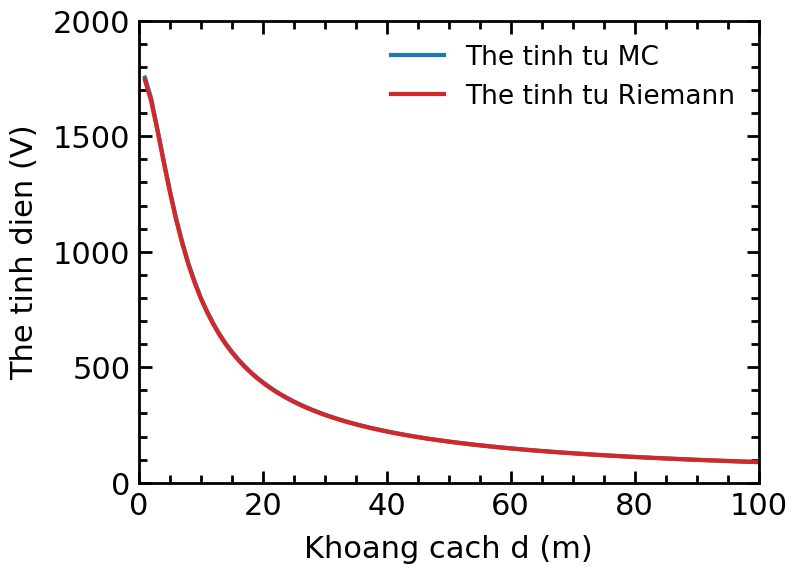

In [18]:
d_tinhdien_Riemann, V_tinhdien_Riemann = np.loadtxt("KQ_Riemann_hinhxuyen.txt", comments="#", unpack=True)

plt.figure(figsize=(8,6))
plt.plot(d_tinhdien, V_tinhdien, label="The tinh tu MC", color="C0", lw = 3)
plt.plot(d_tinhdien_Riemann, V_tinhdien_Riemann, label="The tinh tu Riemann", color="C1", lw = 3)


plt.xlabel("Khoang cach d (m)")
plt.ylabel("The tinh dien (V)")
plt.ylim(0,2000)
plt.xlim(0,100)
plt.legend()
plt.savefig("so_sanh_tinh_dien_MC_riemann.png", dpi = 300)
plt.show()